# HP 8673H -> E4403B frequency sweep

Signal generator output feeds the spectrum analyzer input through a coupler. Steps the generator's CW frequency from 2.5 to 3.0 GHz in 1 MHz increments, reads the analyzer's amplitude at each point, and plots frequency vs. power.

Output power is kept low (-20 dBm at the generator) to avoid reflections into the load / overloading the analyzer input.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from hp8673h import HP8673H
from e4403b import E4403B
from frequency_sweep import frequency_sweep

In [2]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")

START_HZ = 2.5e9
STOP_HZ = 3.0e9
STEP_HZ = 1e6

sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

HP8673H: connected
E4403B: connected


In [3]:
freqs_hz, power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=STEP_HZ,
    power_dbm=-20,
)

gen.close()
sa.close()

print(f"{len(freqs_hz)} points collected")

501 points collected


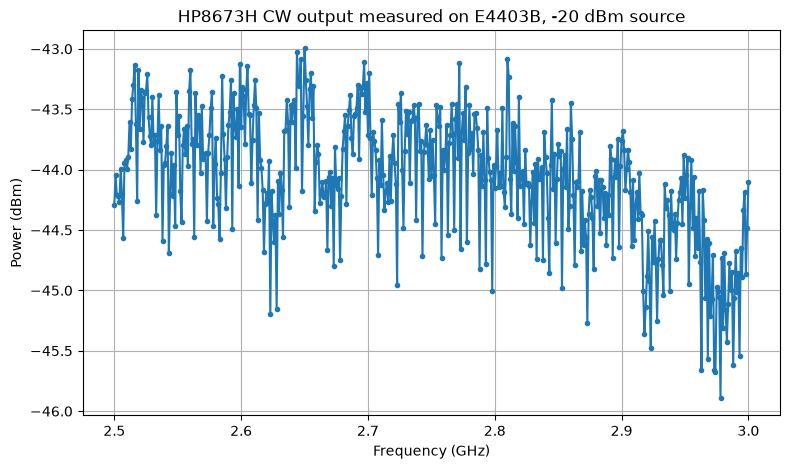

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(freqs_hz / 1e9, power_dbm, marker='.')
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Power (dBm)")
ax.set_title("HP8673H CW output measured on E4403B, -20 dBm source")
ax.grid(True)
plt.show()

In [ ]:
data = np.column_stack((freqs_hz, power_dbm))
np.savetxt(
    "data/frequency_sweep_2.5-3.0GHz_1MHz.csv",
    data,
    delimiter=",",
    header="frequency_hz,power_dbm",
    comments="",
)